# HCC Failure Examples (CUB / Aircraft)

Obiettivo: visualizzare casi in cui al livello fine
- `independent` sbaglia
- `top-down` è corretto

Per ogni caso mostriamo 3 pannelli:
1. immagine query
2. immagine di riferimento della classe GT
3. immagine di riferimento della classe predetta da `independent`

In questo modo il motivo dell'errore è più interpretabile visivamente (classi molto simili tra loro).


In [7]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch

REPO_ROOT = Path('/home/g.saggini1/lexicographic_deep_learning_detailed_study')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from train.config_loader import load_config
from datasets import build_dataloader
from models import build_model
from train.metrics import decoded_preds

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')

DEFAULT_RUNS = {
    'cub200_step100': OUTPUTS_ROOT / 'hcast_hcc_cub200_step_100epochs',
    'aircraft_step100': OUTPUTS_ROOT / 'hcast_hcc_aircraft_step_100epochs',
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


In [8]:
def _final_scores(output):
    logits = output['logits_per_level']
    eff = output.get('effective_probs_per_level')
    if isinstance(eff, list) and len(eff) == len(logits):
        return eff
    return logits


def _denormalize_image(img_tensor, mean, std):
    x = img_tensor.detach().cpu().float().clone()
    for c in range(min(3, x.size(0))):
        x[c] = x[c] * float(std[c]) + float(mean[c])
    x = x.permute(1, 2, 0).numpy()
    return np.clip(x, 0.0, 1.0)


def _meta_id(meta):
    if not isinstance(meta, dict):
        return str(meta)
    for key in ['image_id', 'variant_name', 'class', 'index']:
        if key in meta:
            return f'{key}={meta[key]}'
    return str(meta)


def _class_indices(dataset, level=2):
    out = {}
    for idx, sample in enumerate(getattr(dataset, 'samples', [])):
        labels = sample.get('labels')
        if not isinstance(labels, (list, tuple)) or level >= len(labels):
            continue
        cid = int(labels[level])
        out.setdefault(cid, []).append(idx)
    return out


def _build_class_reference_cache(dataset, class_to_indices, mean, std, level=2):
    cache = {}
    for class_id, idxs in class_to_indices.items():
        if not idxs:
            continue
        idx = idxs[0]
        img_t, labels_t, meta = dataset[idx]
        cache[int(class_id)] = {
            'image': _denormalize_image(img_t, mean, std),
            'meta': meta,
            'path': labels_t.tolist() if hasattr(labels_t, 'tolist') else labels_t,
            'dataset_idx': int(idx),
        }
    return cache


In [9]:
@torch.no_grad()
def collect_topdown_wins_with_references(
    run_dir: Path,
    split='test',
    max_cases=24,
    require_parent_correct=True,
):
    cfg_path = run_dir / 'config_resolved.yaml'
    ckpt_path = run_dir / 'best.pt'
    if not cfg_path.exists():
        raise FileNotFoundError(f'Missing config_resolved.yaml in {run_dir}')
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Missing best.pt in {run_dir}')

    cfg, _ = load_config(str(cfg_path), [])
    if hasattr(cfg, 'dataloader') and hasattr(cfg.dataloader, 'num_workers'):
        cfg.dataloader.num_workers = 0

    loader, num_classes_per_level, taxonomy = build_dataloader(cfg, split=split)
    dataset = loader.dataset

    model = build_model(cfg, num_classes_per_level, taxonomy).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    mean = list(cfg.dataset.get('mean', [0.485, 0.456, 0.406]))
    std = list(cfg.dataset.get('std', [0.229, 0.224, 0.225]))

    class_to_indices = _class_indices(dataset, level=2)
    ref_cache = _build_class_reference_cache(dataset, class_to_indices, mean, std, level=2)

    cases = []
    for images, labels, metas in loader:
        images_dev = images.to(device, non_blocking=True)
        labels_dev = labels.to(device, non_blocking=True)

        output = model(images_dev)
        scores = _final_scores(output)

        pred_ind = decoded_preds(scores, taxonomy=taxonomy, enforce_hierarchy=False)
        pred_td = decoded_preds(scores, taxonomy=taxonomy, enforce_hierarchy=True)

        if len(pred_ind) < 3 or len(pred_td) < 3:
            continue

        # independent wrong at fine, top-down correct at fine
        mask = pred_ind[2].ne(labels_dev[:, 2]) & pred_td[2].eq(labels_dev[:, 2])
        if require_parent_correct:
            mask = mask & pred_td[1].eq(labels_dev[:, 1])

        idxs = torch.nonzero(mask, as_tuple=False).flatten().tolist()
        for i in idxs:
            gt_fine = int(labels[i, 2].item())
            ind_fine = int(pred_ind[2][i].item())

            if gt_fine not in ref_cache or ind_fine not in ref_cache:
                continue

            case = {
                'query_image': _denormalize_image(images[i], mean, std),
                'query_meta': metas[i],
                'true': labels[i].tolist(),
                'pred_ind': [int(p[i].item()) for p in pred_ind],
                'pred_td': [int(p[i].item()) for p in pred_td],
                'gt_ref': ref_cache[gt_fine],
                'ind_ref': ref_cache[ind_fine],
            }
            cases.append(case)
            if len(cases) >= max_cases:
                return cases

    return cases


In [10]:
def show_triplet_cases(cases, title='', max_cases=8):
    if not cases:
        print('No cases found.')
        return

    cases = cases[:max_cases]
    n = len(cases)
    fig, axes = plt.subplots(n, 3, figsize=(14, 4.1 * n), squeeze=False)

    for r, case in enumerate(cases):
        ax_q, ax_gt, ax_ind = axes[r]

        ax_q.imshow(case['query_image'])
        ax_q.axis('off')
        q_meta = _meta_id(case.get('query_meta'))
        ax_q.set_title(
            'Query\n'
            f'{q_meta}\n'
            f"GT={case['true']}\n"
            f"IND={case['pred_ind']}\n"
            f"TD={case['pred_td']}",
            fontsize=9,
        )

        ax_gt.imshow(case['gt_ref']['image'])
        ax_gt.axis('off')
        ax_gt.set_title(
            'Reference GT class\n'
            f"fine={case['true'][2]} | {_meta_id(case['gt_ref'].get('meta'))}",
            fontsize=9,
        )

        ax_ind.imshow(case['ind_ref']['image'])
        ax_ind.axis('off')
        ax_ind.set_title(
            'Reference IND-pred class\n'
            f"fine={case['pred_ind'][2]} | {_meta_id(case['ind_ref'].get('meta'))}",
            fontsize=9,
        )

    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


CUB cases found: 20


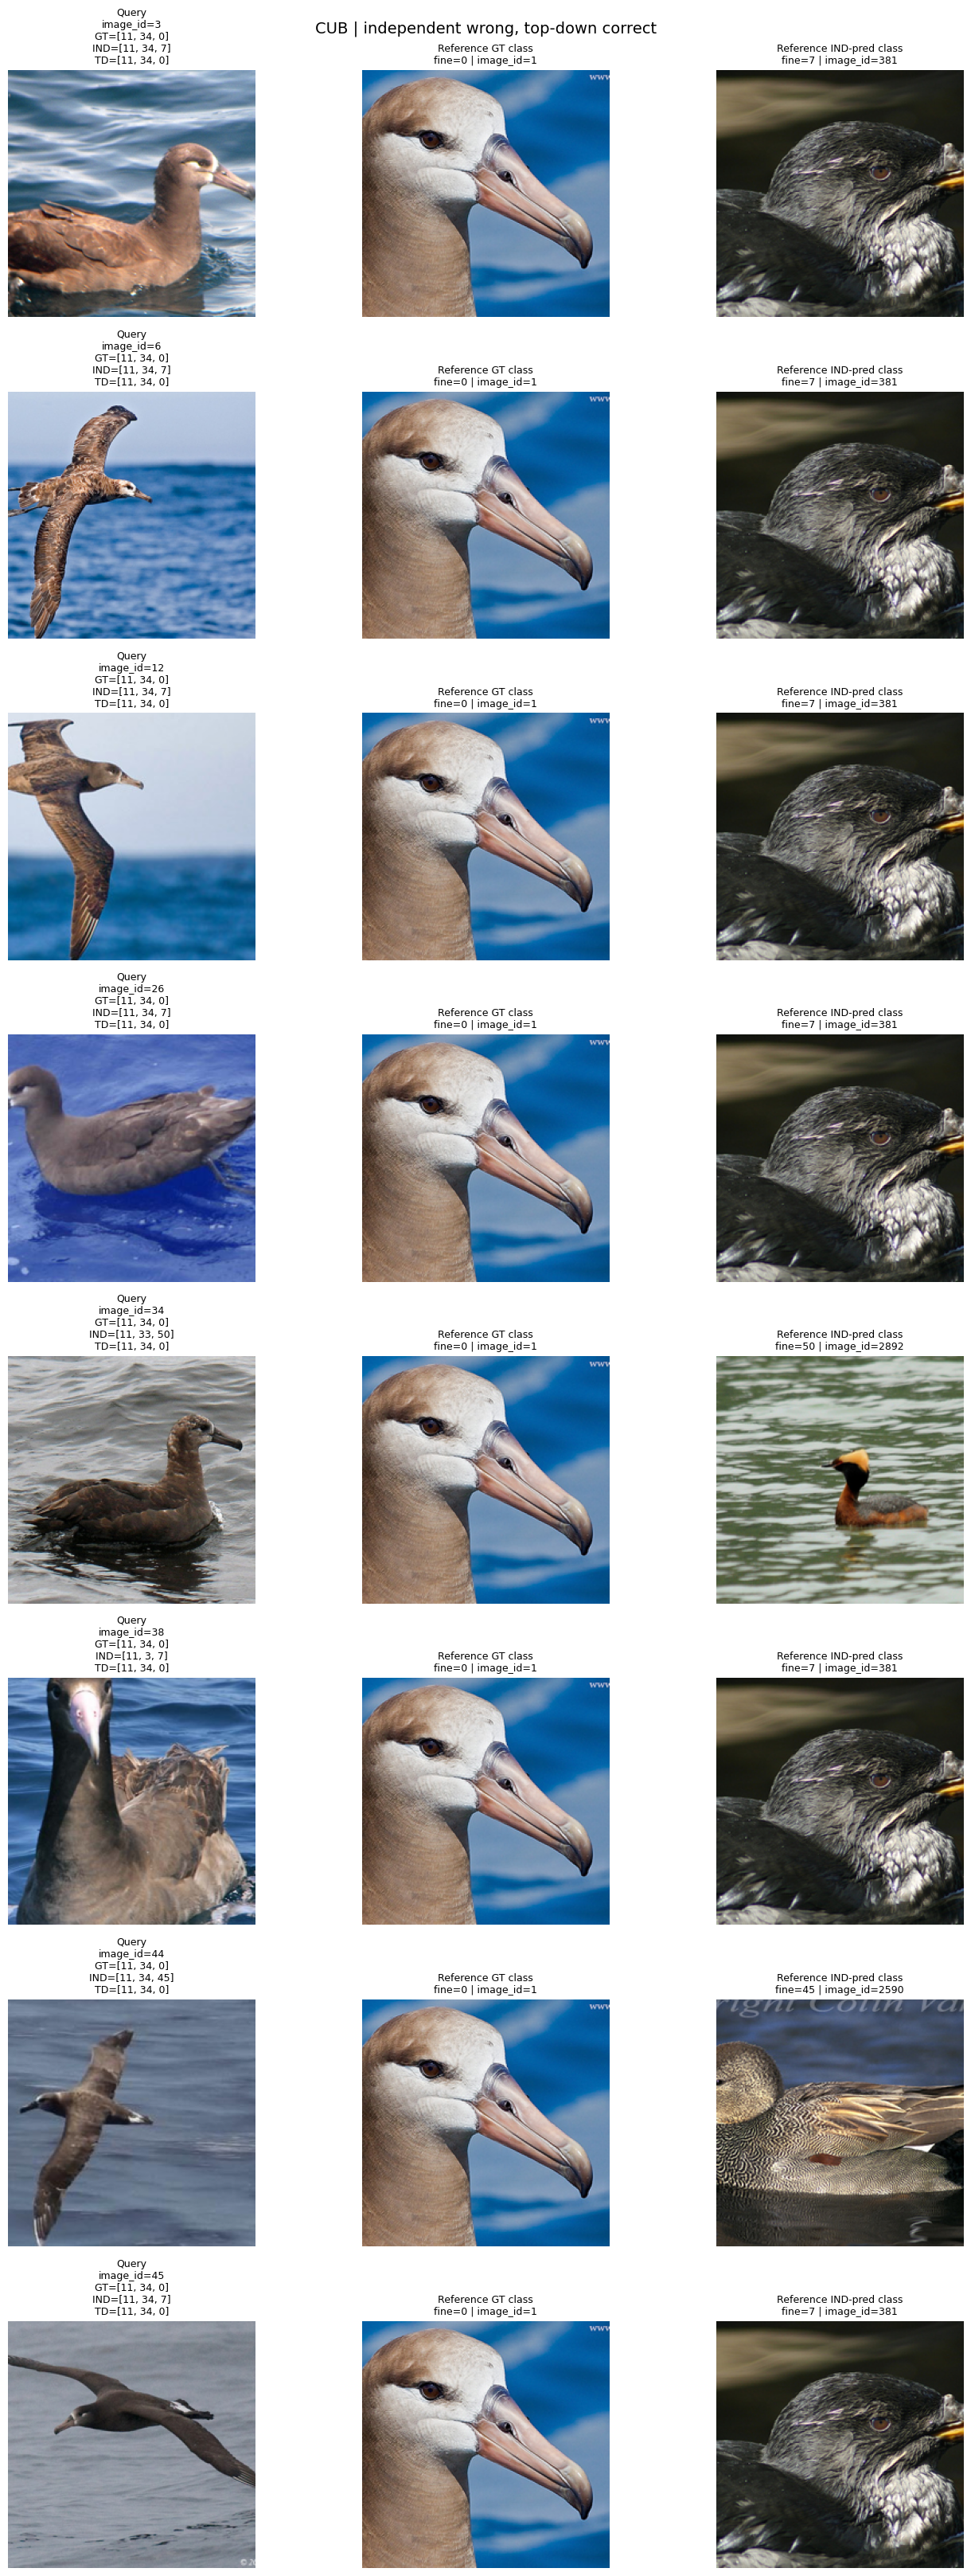

In [11]:
# CUB: casi dove TD corregge l'errore di independent
cub_cases = collect_topdown_wins_with_references(
    DEFAULT_RUNS['cub200_step100'],
    split='test',
    max_cases=20,
    require_parent_correct=True,
)
print('CUB cases found:', len(cub_cases))
show_triplet_cases(cub_cases, title='CUB | independent wrong, top-down correct', max_cases=8)


Aircraft cases found: 20


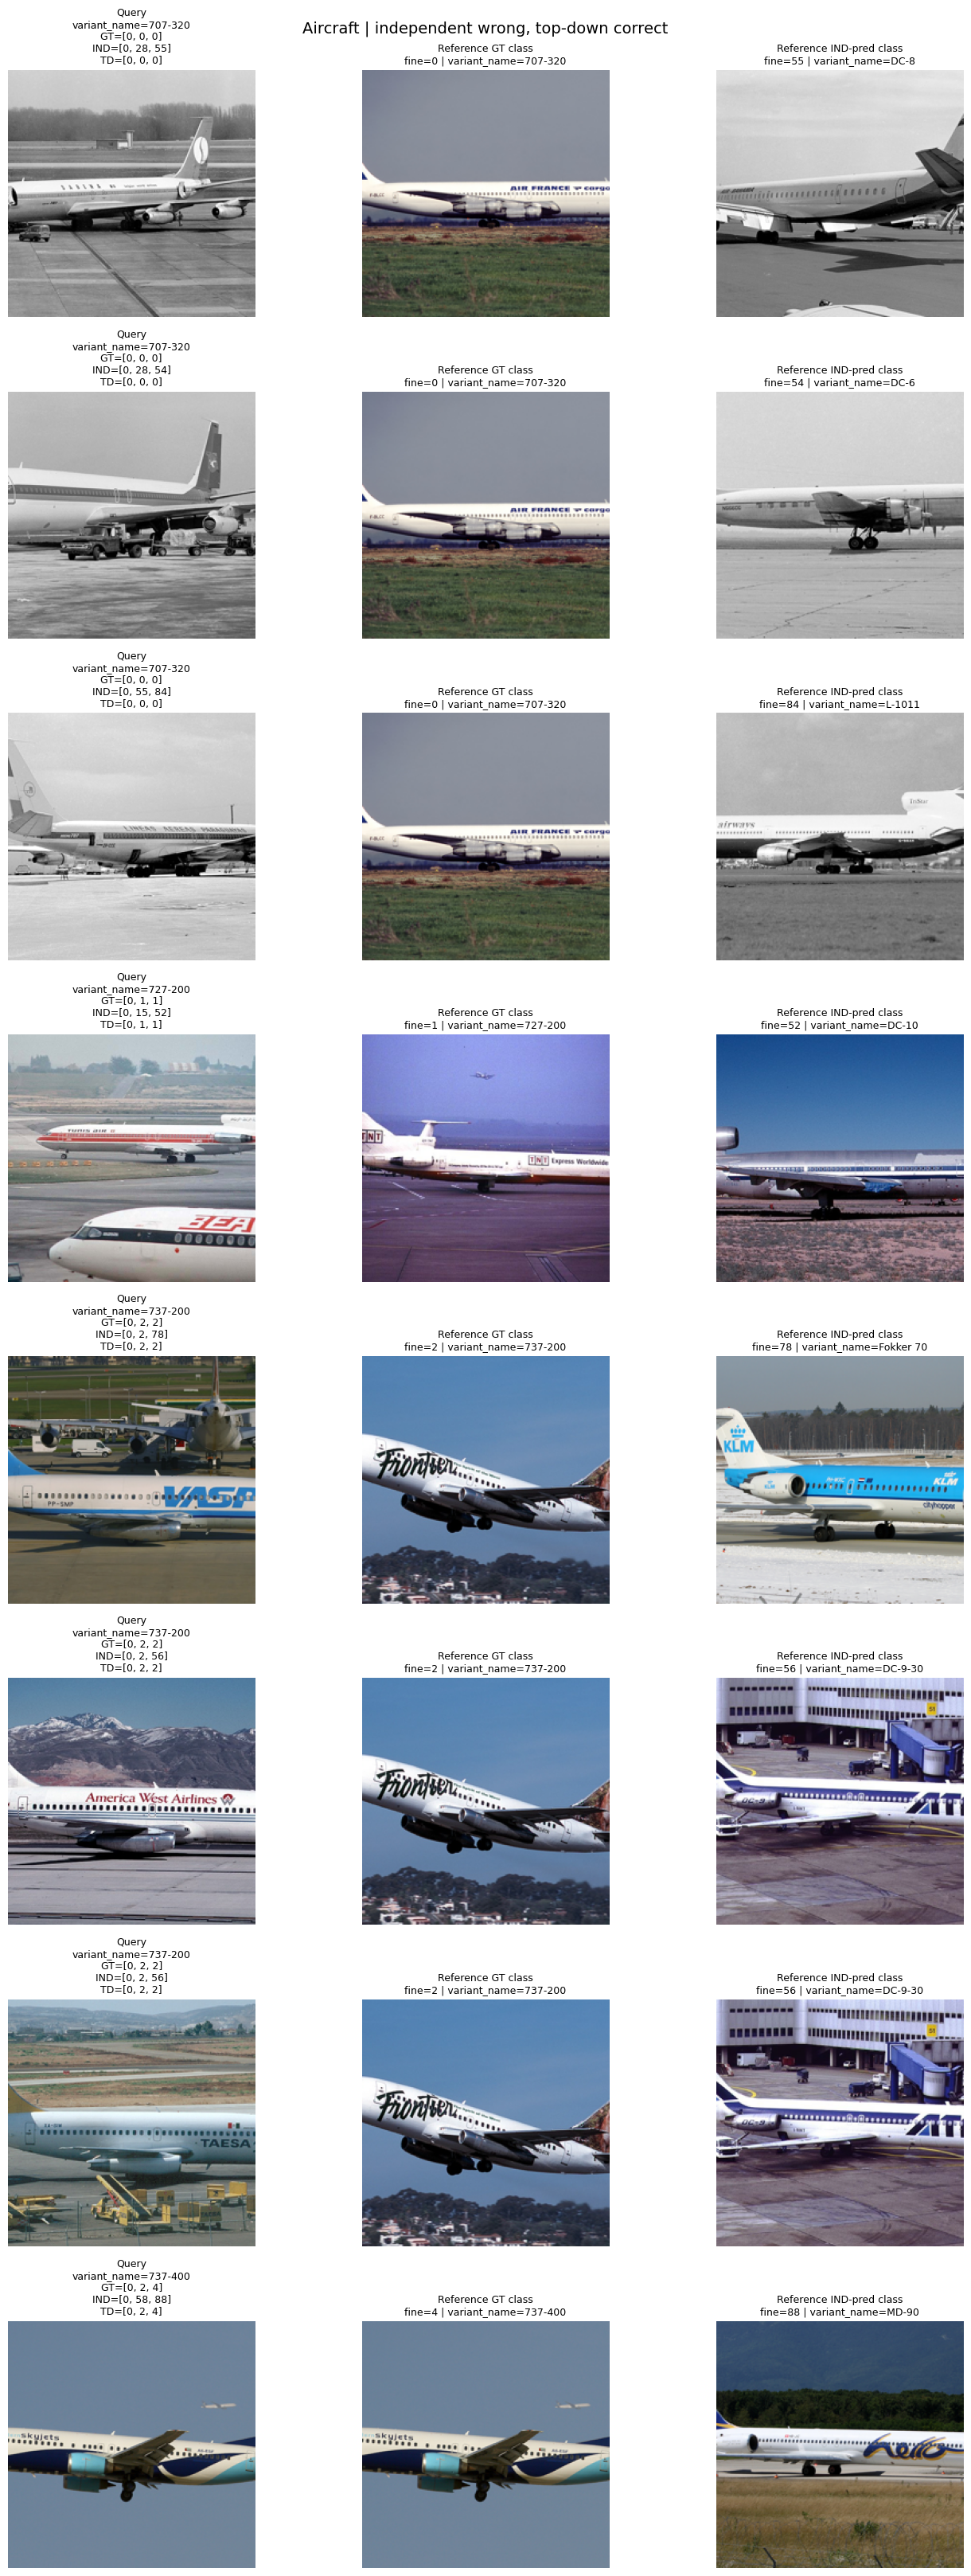

In [12]:
# Aircraft: casi dove TD corregge l'errore di independent
air_cases = collect_topdown_wins_with_references(
    DEFAULT_RUNS['aircraft_step100'],
    split='test',
    max_cases=20,
    require_parent_correct=True,
)
print('Aircraft cases found:', len(air_cases))
show_triplet_cases(air_cases, title='Aircraft | independent wrong, top-down correct', max_cases=8)


## Lettura dei pannelli

- Se la `Query` è visivamente più simile alla `Reference IND-pred class` che alla GT, l'errore è plausibilmente semantico (classi vicine).
- Se invece la `Query` è simile alla GT ma `independent` sbaglia, il problema è più probabilmente di ranking/massa tra siblings introdotto da HCC.
- `top-down` corretto con `independent` sbagliato indica che il path gerarchico è buono, ma la scelta fine globale non lo è.
